In [17]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sns.set_theme(style="whitegrid")

In [18]:
df = pd.read_csv("../data/raw/online_retail_II.csv")

Cleaning the data for further analysis.

<b>1. Removing Cancellations & Returns

In [19]:
print(f"Original row count: {len(df):,}")
initial_length = len(df)

Original row count: 1,067,371


In [20]:
# Remove rows where InvoiceNo starts with 'C' (Cancellations)
# Convert to string first to avoid errors on any unexpected numeric types
df_cleaned = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove rows where Quantity is less than or equal to 0 (Returns/Adjustments)
df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0]

print(f"Row count after removing cancellations and negative order quantities: {len(df_cleaned):,}")
print(f"Total rows removed: {len(df) - len(df_cleaned):,}")

# Update 'df' for the next step
df = df_cleaned.copy()

Row count after removing cancellations and negative order quantities: 1,044,420
Total rows removed: 22,951


<b>2. Removing `Price <= 0`

In [21]:
print(f"Row count before removing price anomalies: {len(df):,}")

# Keep only rows where the Price > 0
df_cleaned = df[df['Price'] > 0]

print(f"Row count after removing Price <= 0: {len(df_cleaned):,}")
print(f"Total price anomalies removed: {len(df) - len(df_cleaned):,}")

# Update 'df' for the next step
df = df_cleaned.copy()

Row count before removing price anomalies: 1,044,420
Row count after removing Price <= 0: 1,041,670
Total price anomalies removed: 2,750


<b>3. Removing non-product Stock Codes

In [22]:
print(f"Row count before removing non-product codes: {len(df):,}")

# Regex pattern: exactly 5 digits, followed by an optional single letter
valid_pattern = r'^\d{5}[a-zA-Z]?$'

# 1. Convert to string
# 2. Strip leading/trailing whitespaces
# 3. Keep only rows that match the regex pattern
df_cleaned = df[df['StockCode'].astype(str).str.strip().str.match(valid_pattern)]

print(f"Row count after Step 3: {len(df_cleaned):,}")
print(f"Total non-product codes removed: {len(df) - len(df_cleaned):,}")

# Update 'df' for the next step
df = df_cleaned.copy()

Row count before removing non-product codes: 1,041,670
Row count after Step 3: 1,035,621
Total non-product codes removed: 6,049


<b>4. Cleaning Missing/Invalid Descriptions</b><br>
Our analysis from `01_initial_data_look.ipynb` showed there are empty product `Description` fields which are likely to be system errors.<br>
Since we've already cleaned out Price <= 0 (which are tied to these descriptions), we must've already filtered them out. However, just to be sure, let us see if there are any of these descriptions left. 

In [23]:
# Create a mask for rows where Description is null OR contains a '?'
invalid_desc_mask = df['Description'].isna() | df['Description'].str.contains('?', regex=False, na=False)

# Example of what we are about to remove
print("Sample of rows with missing or '?' descriptions:")

display(df[invalid_desc_mask].head())

print(f"Number of remaining invalid descriptions: {len(df[invalid_desc_mask])}")

Sample of rows with missing or '?' descriptions:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


Number of remaining invalid descriptions: 0


As we suspected, we have already filtered out invalid and missing descriptions from step 2.

In [24]:
# Keep only the rows that DO NOT match the invalid mask
df_cleaned = df[~invalid_desc_mask]

print(f"Row count after removing invalid descriptions: {len(df_cleaned):,}")

# Update 'df' for the next step
df = df_cleaned.copy()

Row count after removing invalid descriptions: 1,035,621


<b>5. Removing Non-UK Transactions</b><br>
Since majority of the transactions occur in the UK, we focus our analysis only on UK transactions.

In [25]:
print(f"Row count before removing Non-UK transactions: {len(df):,}")

# Keep only transactions where the Country is 'United Kingdom'
df_cleaned = df[df['Country'] == 'United Kingdom']

print(f"Row count after Step 5: {len(df_cleaned):,}")
print(f"Total international transactions removed: {len(df) - len(df_cleaned):,}")

# Update 'df' for the next step
df = df_cleaned.copy()

Row count before removing Non-UK transactions: 1,035,621
Row count after Step 5: 954,730
Total international transactions removed: 80,891


Here is how much data we can use after cleaning (% usable data):

Total rows in raw dataset: 1,067,371
Usable rows remaining after cleaning: 954,730
Data retention rate: 89.45%


[None, None, None, None, None, None]

[None, None]

Text(0.5, 1.0, '% Usable Data')

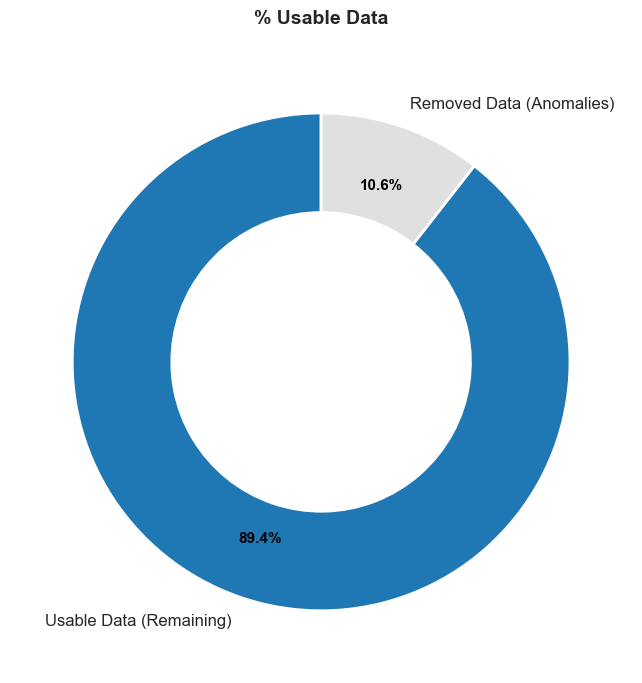

In [26]:
rows_remaining = len(df)
rows_removed = initial_length - rows_remaining
retention_pct = (rows_remaining / initial_length) * 100

print(f"Total rows in raw dataset: {initial_length:,}")
print(f"Usable rows remaining after cleaning: {rows_remaining:,}")
print(f"Data retention rate: {retention_pct:.2f}%")

# Create the visual
labels = ['Usable Data (Remaining)', 'Removed Data (Anomalies)']
sizes = [rows_remaining, rows_removed]
colors = ['#1f77b4','#e0e0e0'] 

fig, ax = plt.subplots(figsize=(7, 7))

# Plot a pie chart with a 'width' parameter to turn it into a donut chart
wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=90, 
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)

# Style the text for better readability
plt.setp(autotexts, size=11, weight="bold", color="black")
plt.setp(texts, size=12)

plt.title('% Usable Data', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

<b>6. Base Feature Extraction</b><br>
We extract time and revenue features from this dataset: `day`, `year`, `week`, `Revenue` 

In [29]:
print("Extracting time and revenue features...")

# 1. Ensure InvoiceDate is properly formatted as a datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Extract specific time components
df['date'] = df['InvoiceDate'].dt.date
df['year'] = df['InvoiceDate'].dt.year
df['month'] = df['InvoiceDate'].dt.month
df['week'] = df['InvoiceDate'].dt.isocalendar().week  # ISO week number

# 3. Calculate Revenue
df['Revenue'] = df['Quantity'] * df['Price']

print("Here is a sample of our fully cleaned dataset with basic features:")
display(df.head())

Extracting time and revenue features...
Here is a sample of our fully cleaned dataset with basic features:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,date,year,month,week,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12-01,2009,12,49,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009,12,49,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009,12,49,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12-01,2009,12,49,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01,2009,12,49,30.0
